In [1]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
import cv2
import os
import pandas as pd
import random as rd
from PIL import Image, ImageOps
import copy

In [2]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

Using device: cuda


In [3]:
def set_seed(seed=42):
    rd.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(13)

In [4]:
os.environ["HF_HUB_TIMEOUT"] = "300"
os.environ["HF_HUB_READ_TIMEOUT"] = "300"
os.environ["HF_DATASETS_DOWNLOAD_TIMEOUT"] = "300"

In [5]:
from datasets import load_dataset

ds = load_dataset("nf-whoi/whoi-plankton-small")

In [6]:
tmp_img = ds['train'][5]['image']
tmp_img = np.array(tmp_img)
h, w = tmp_img.shape
print(f'Height: {h}, Width: {w}')
for i in range(3):
  h_start = np.random.randint(0, (h-(h*(1/6))))
  w_start = np.random.randint(0, (w-(w*(1/6))))
  tmp_img[h_start:int(h_start+h*(1/5)), w_start:int(w_start+w*(1/5))] = 0
tmp_img

Height: 95, Width: 155


array([[199, 198, 198, ..., 201, 200, 200],
       [193, 197, 195, ..., 204, 201, 200],
       [200, 197, 197, ..., 197, 200, 202],
       ...,
       [199, 194, 197, ..., 199, 200, 202],
       [196, 195, 194, ..., 199, 197, 198],
       [194, 198, 200, ..., 202, 200, 204]], shape=(95, 155), dtype=uint8)

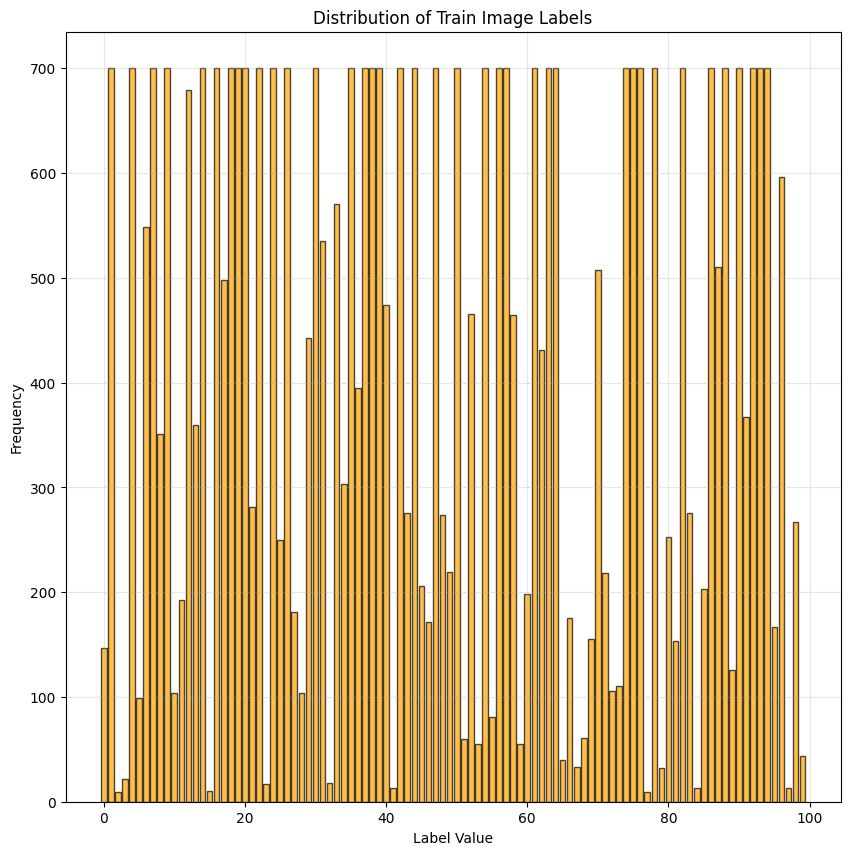

In [7]:
from collections import Counter

plt.figure(figsize=(10, 10))
label_counts = Counter(ds['train'][:]['label'])

labels = list(label_counts.keys())
counts = list(label_counts.values())

plt.bar(labels, counts, color='orange', alpha=0.7, edgecolor='black')
plt.xlabel('Label Value')
plt.ylabel('Frequency')
plt.title('Distribution of Train Image Labels')
plt.grid(True, alpha=0.3)
plt.show()

In [8]:
weighted_class = [(len(ds['train']) / (100 * label_counts[i])) for i in label_counts]

In [9]:
def salt_pepper(img, prob):
  tmp = np.copy(img)
  matrix = np.random.rand(tmp.shape[0], tmp.shape[1])
  prob = 0.05
  tmp[matrix < prob/2] = 0
  tmp[matrix > 1-prob/2] = 255
  tmp = Image.fromarray(tmp)
  return tmp

In [10]:
train_img = []
size = 64

for data in ds['train']:
    img = np.array(data['image'].convert("L").resize((64, 64)), dtype=np.float32) / 255.0
    label = data['label']

    for i in range(3):
      rot_img = np.array(
          data['image'].convert("L").rotate(np.random.randint(180), expand=True).resize((64, 64)),
          dtype=np.float32
      ) / 255.0
      train_img.append({"image": rot_img,  "label": label})

    for i in range(3):
      mask_img = np.array(data['image'].convert("L"), dtype=np.float32)
      h, w = mask_img.shape
      for _ in range(3):
          h_start = np.random.randint(0, int(h - h / 6))
          w_start = np.random.randint(0, int(w - w / 6))
          mask_img[h_start:int(h_start + h/5), w_start:int(w_start + w/5)] = 0
      mask_img = np.array(Image.fromarray(mask_img).resize((64, 64)), dtype=np.float32) / 255.0
      train_img.append({"image": mask_img, "label": label})

    mirror = np.array(ImageOps.mirror(Image.fromarray((img * 255).astype(np.uint8))), dtype=np.float32) / 255.0
    flip   = np.array(ImageOps.flip(Image.fromarray((img * 255).astype(np.uint8))), dtype=np.float32) / 255.0
    sp     = np.array(salt_pepper(img, 0.1), dtype=np.float32)

    train_img.append({"image": img,      "label": label})
    train_img.append({"image": mirror,   "label": label})
    train_img.append({"image": flip,     "label": label})
    train_img.append({"image": sp,       "label": label})

len(train_img)

405990

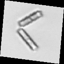

In [11]:
img_show = (train_img[0]['image'] * 255).astype(np.uint8)
img_show = Image.fromarray(img_show)

img_show

In [12]:
#train_img = train_img[:int(len(train_img)*0.5)]

In [13]:
labels = []
for data in train_img:
  label = data['label']
  labels.append(label)

np.unique(labels)

array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16,
       17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33,
       34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50,
       51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67,
       68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84,
       85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99])

In [ ]:
class ResDepthConv(nn.Module):
  def __init__(self, in_channels, out_channels):
    super().__init__()
    self.proj = nn.Sequential(nn.Conv2d(in_channels, out_channels, 1), nn.BatchNorm2d(out_channels))
    self.relu = nn.ReLU()
    self.network = nn.Sequential(
            nn.Conv2d(in_channels, in_channels, 3, padding=1, groups=in_channels), nn.BatchNorm2d(in_channels), nn.ReLU(),
            nn.Conv2d(in_channels, out_channels, 1), nn.BatchNorm2d(out_channels), nn.ReLU(),
            nn.Conv2d(out_channels, out_channels, 3, padding=1, groups=out_channels),nn.BatchNorm2d(out_channels), nn.ReLU(),
            nn.Conv2d(out_channels, out_channels, 1), nn.BatchNorm2d(out_channels)
        )

  def forward(self, x):
    out = self.network(x)
    out = out + self.proj(x)
    return self.relu(out)

In [ ]:
class PlanktonResCNN(nn.Module):
  def __init__(self):
    super().__init__()
    self.linear = nn.Sequential(nn.AdaptiveAvgPool2d(1), nn.Flatten(), nn.Linear(256, 100))
    self.network = nn.Sequential(
            ResDepthConv(1, 32), nn.MaxPool2d(2),
            ResDepthConv(32, 64), nn.MaxPool2d(2),
            ResDepthConv(64, 128), nn.MaxPool2d(2),
            ResDepthConv(128, 256),
        )

  def forward(self, x):
      out = self.network(x)
      return self.linear(out)

model = PlanktonResCNN().to(device)

In [17]:
from torch.utils.data import DataLoader, TensorDataset

data_train_x = []
for data in train_img:
  data_train_x.append(data['image'])
data_train_x = np.array(data_train_x)
data_train_x = torch.tensor(data_train_x, dtype=torch.float32)
print(data_train_x.shape)

data_train_y = []
for data in train_img:
  data_train_y.append(data['label'])
data_train_y = np.array(data_train_y)
data_train_y = torch.tensor(data_train_y, dtype=torch.long)
print(data_train_y.shape)

train_dataset = TensorDataset(data_train_x, data_train_y)

batch_size = 256
dataloader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

torch.Size([405990, 64, 64])
torch.Size([405990])


In [18]:
val_img = []

for data in ds['validation']:
  img = data['image'].convert("L").resize((size,size))
  img = np.array(img) / 255.0
  tmp = ({
      "image": img,
      "label": data['label']
  })
  val_img.append(tmp)

len(val_img)

5799

In [19]:
criterion = nn.CrossEntropyLoss(weight=torch.tensor(weighted_class).to(device))
optimizer = optim.Adam(model.parameters(), lr=1e-4)

In [20]:
val_loss_hist = []
val_acc_hist = []
loss_hist = []
acc_hist = []
log_file = "training2.log"
best_model = copy.deepcopy(model)
best_val_acc = 0

epochs = 200
for epoch in range(epochs):
  running_loss = 0.0
  correct = 0

  model.train()
  for inputs, labels in dataloader:
    inputs = inputs.to(device)
    labels = labels.to(device)
    inputs = inputs.unsqueeze(1)
    optimizer.zero_grad()

    outputs = model(inputs)
    loss = criterion(outputs, labels)
    loss.backward()
    optimizer.step()
    running_loss += loss.item()

    softmax = nn.Softmax(dim=1)
    probs = softmax(outputs)
    correct += (torch.argmax(probs, dim=1) == labels).sum().item()

  avg_loss = running_loss / len(dataloader)
  accuracy = correct / len(train_img)
  loss_hist.append(avg_loss)
  acc_hist.append(accuracy)

  model.eval()
  correct_val = 0
  val_loss = 0.0
  with torch.no_grad():
    for data in val_img:
      img = torch.tensor(data['image'], dtype=torch.float32)
      label = torch.tensor(data['label'], dtype=torch.long)
      img = img.unsqueeze(0).unsqueeze(0).to(device)
      label = label.unsqueeze(0).to(device)

      outputs = model(img)
      loss = criterion(outputs, label)
      val_loss += loss.item()
      softmax = nn.Softmax(dim=1)
      probs = softmax(outputs)
      predicted_label = torch.argmax(probs, dim=1)
      correct_val += (predicted_label == label).sum().item()
  avg_val_loss = val_loss / len(val_img)
  val_acc = correct_val / len(val_img)
  val_loss_hist.append(avg_val_loss)
  val_acc_hist.append(val_acc)
  if val_acc > best_val_acc:
      best_val_acc = val_acc
      best_model = copy.deepcopy(model)
  log_line = f"Epoch [{epoch+1}/{epochs}] - Average loss: {avg_loss:.4f} - Accuracy: {accuracy:.4f} - Val_Loss: {avg_val_loss:.4f} - Val_Acc: {val_acc:.4f}"
  print(log_line)
  with open(log_file, "a") as f:
      f.write(log_line + "\n")

Epoch [1/200] - Average loss: 2.6581 - Accuracy: 0.0563 - Val_Loss: 4.0451 - Val_Acc: 0.0950
Epoch [2/200] - Average loss: 1.8349 - Accuracy: 0.1380 - Val_Loss: 3.5440 - Val_Acc: 0.1743
Epoch [3/200] - Average loss: 1.5505 - Accuracy: 0.1978 - Val_Loss: 2.6633 - Val_Acc: 0.2959
Epoch [4/200] - Average loss: 1.3729 - Accuracy: 0.2527 - Val_Loss: 2.3036 - Val_Acc: 0.3552
Epoch [5/200] - Average loss: 1.2415 - Accuracy: 0.2969 - Val_Loss: 2.1467 - Val_Acc: 0.4042
Epoch [6/200] - Average loss: 1.1395 - Accuracy: 0.3351 - Val_Loss: 2.0220 - Val_Acc: 0.4292
Epoch [7/200] - Average loss: 1.0513 - Accuracy: 0.3668 - Val_Loss: 2.1050 - Val_Acc: 0.4239
Epoch [8/200] - Average loss: 0.9768 - Accuracy: 0.3957 - Val_Loss: 2.2142 - Val_Acc: 0.4135
Epoch [9/200] - Average loss: 0.9108 - Accuracy: 0.4220 - Val_Loss: 1.8596 - Val_Acc: 0.4894
Epoch [10/200] - Average loss: 0.8537 - Accuracy: 0.4443 - Val_Loss: 1.7305 - Val_Acc: 0.5135
Epoch [11/200] - Average loss: 0.7982 - Accuracy: 0.4662 - Val_Loss: 

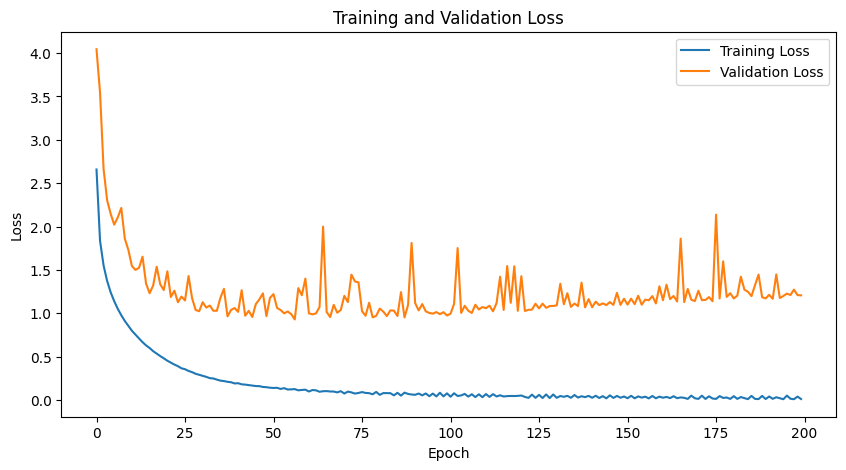

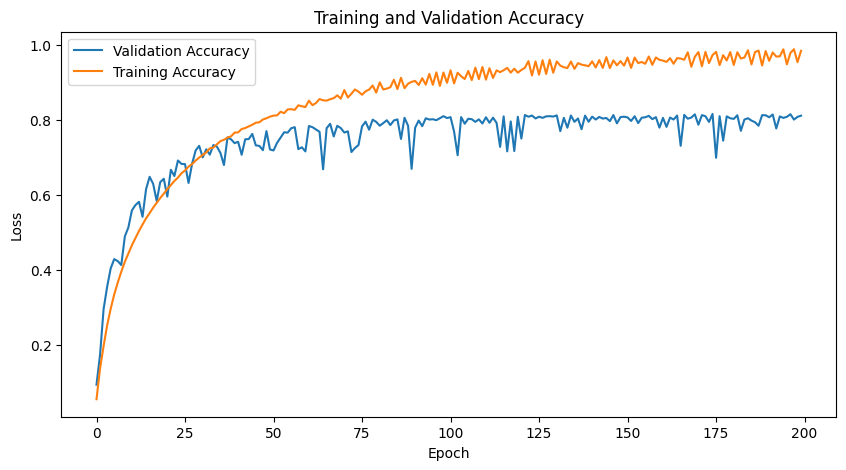

In [21]:
plt.figure(figsize=(10, 5))
plt.plot(loss_hist, label='Training Loss')
plt.plot(val_loss_hist, label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.title('Training and Validation Loss')
plt.savefig("loss_curve2.png", dpi=300, bbox_inches="tight")
plt.show()

plt.figure(figsize=(10, 5))
plt.plot(val_acc_hist, label='Validation Accuracy')
plt.plot(acc_hist, label='Training Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.title('Training and Validation Accuracy')
plt.savefig("accuracy_curve2.png", dpi=300, bbox_inches="tight")
plt.show()

In [28]:
total = sum(p.numel() for p in model.parameters())
trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"Total params: {total:,}")
print(f"Trainable: {trainable:,}")
print(f"Frozen: {total-trainable:,}")

Total params: 1,243,780
Trainable: 1,243,780
Frozen: 0


In [29]:
test_img = []

for data in ds['test']:
  img = data['image'].convert("L").resize((size,size))
  img = np.array(img) / 255.0
  tmp = ({
      "image": img,
      "label": data['label']
  })
  test_img.append(tmp)

len(test_img)

11601

In [30]:
model.eval()
with torch.no_grad():
  correct = 0
  total_samples = 0
  for data in test_img:
    img = torch.tensor(data['image'], dtype=torch.float32)
    label = torch.tensor(data['label'], dtype=torch.long)

    img = img.unsqueeze(0).unsqueeze(0).to(device)
    label = label.unsqueeze(0).to(device)

    outputs = best_model(img)

    softmax = nn.Softmax(dim=1)
    probs = softmax(outputs)
    predicted_label = torch.argmax(probs, dim=1)
    correct += (predicted_label == label).sum().item()
    total_samples += 1

  accuracy = correct / total_samples
  test_acc = f'Accuracy: {accuracy:.4f}'
  print(f'Accuracy: {accuracy:.4f}')
  with open(log_file, "a") as f:
      f.write(test_acc + "\n")

Accuracy: 0.8117


In [31]:
model.eval()
with torch.no_grad():
  correct = 0
  total_samples = 0
  for data in val_img:
    img = torch.tensor(data['image'], dtype=torch.float32)
    label = torch.tensor(data['label'], dtype=torch.long)

    img = img.unsqueeze(0).unsqueeze(0).to(device)
    label = label.unsqueeze(0).to(device)

    outputs = best_model(img)

    softmax = nn.Softmax(dim=1)
    probs = softmax(outputs)
    predicted_label = torch.argmax(probs, dim=1)
    correct += (predicted_label == label).sum().item()
    total_samples += 1

  accuracy = correct / total_samples
  print(f'Accuracy: {accuracy:.4f}')

Accuracy: 0.8155


In [32]:
model.eval()
sample_x = data_train_x[:1].unsqueeze(1).to(device)
sample_y = data_train_y[:1].to(device)

with torch.no_grad():
    out = model(sample_x)
    print("Output shape:", out.shape)
    print("Output sample (logits):", out[0][:10])
    print("Max logit:", out.max().item())
    print("Min logit:", out.min().item())

    loss = criterion(out, sample_y)
    print("Manual loss:", loss.item())

Output shape: torch.Size([1, 100])
Output sample (logits): tensor([ -8.1608, -10.0725, -28.7723, -18.5281,  -9.5076, -19.0384, -21.9653,
         -5.9703, -20.8377, -34.7860], device='cuda:0')
Max logit: 20.12933921813965
Min logit: -56.33546447753906
Manual loss: 1.1920928244535389e-07


In [33]:
softmax = nn.Softmax(dim=1)
probs = softmax(out)
print(torch.argmax(probs, dim=1))

tensor([74], device='cuda:0')


In [ ]:
example_inputs = (torch.randn(1, 1, 64, 64).to(device))
onnx_program = torch.onnx.export(best_model, example_inputs, dynamo=True)
onnx_program.save("resdepth_classifier_model.onnx")

[torch.onnx] Obtain model graph for `PlanktonCNN([...]` with `torch.export.export(..., strict=False)`...
[torch.onnx] Obtain model graph for `PlanktonCNN([...]` with `torch.export.export(..., strict=False)`... ✅
[torch.onnx] Run decomposition...
[torch.onnx] Run decomposition... ✅
[torch.onnx] Translate the graph into ONNX...
[torch.onnx] Translate the graph into ONNX... ✅
Applied 12 of general pattern rewrite rules.


/venv/main/lib/python3.12/copyreg.py:99: FutureWarning: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
  return cls.__new__(cls, *args)
